# Week 10: Data Visualisation with `seaborn` - Class Exercises

We first load the packages necessary for this week's exercises.

Let us use `seaborn` for our visualisations.

In [2]:
# Import numpy for numerical operations (e.g., handling infinity values used later in plots)
import numpy as np
# Import pandas for loading and manipulating tabular data
import pandas as pd
# Import seaborn for high-level statistical charts
import seaborn as sns
# Apply the 'darkgrid' style — gives all charts a dark grey grid background for readability
sns.set_style('darkgrid')

---
# 1. Streaming Services

The file `streamingUS.csv` contains market shares of major streaming service providers in the US between 2020 and 2021. 

(a) Read in and prepare the data in tidy format. The first 5 rows should look like this:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>order</th>
      <th>service</th>
      <th>year</th>
      <th>share</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Netflix</td>
      <td>2020</td>
      <td>29</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Prime</td>
      <td>2020</td>
      <td>21</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Hulu</td>
      <td>2020</td>
      <td>16</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Disney</td>
      <td>2020</td>
      <td>12</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Apple</td>
      <td>2020</td>
      <td>4</td>
    </tr>
  </tbody>
</table>
</div>

In [3]:
# Type your code here:
# Import pandas for reading and reshaping tabular data
import pandas as pd

# Load the US streaming market share CSV file into a DataFrame
df = pd.read_csv("../data/streamingUS.csv")

# Melt to tidy format (wide -> long)
# The original data has one column per year; melt stacks those into a single 'year' column
# id_vars=['order','service'] are the columns to keep as-is; all other columns become rows
df_tidy = df.melt(id_vars=['order', 'service'], 
                   var_name='year',    # the new column that holds the old column names (years)
                   value_name='share') # the new column that holds the corresponding values

# Convert the 'year' column from text (e.g., "2020") to an integer so it sorts and plots correctly
df_tidy['year'] = df_tidy['year'].astype(int)

# Sort rows first by year then by the original display order, and reset row numbers from 0
df_tidy = df_tidy.sort_values(['year', 'order']).reset_index(drop=True)

print(df_tidy.head())

   order  service  year  share
0      1  Netflix  2020     29
1      2    Prime  2020     21
2      3     Hulu  2020     16
3      4   Disney  2020     12
4      5    Apple  2020      4


(b) Re-create the plot below, as closely as you can.

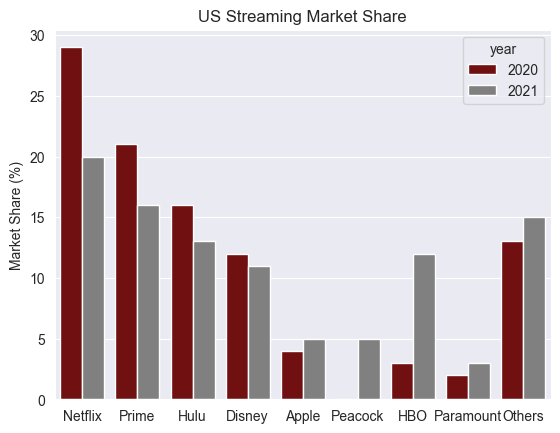

**Hint:**
- Read the documentation for `barplot` here: https://seaborn.pydata.org/generated/seaborn.barplot.html 
- The colours are "maroon" and "grey".

In [4]:
# Import sys to access the current Python interpreter's path
import sys
# Use pip (via the current Python executable) to quietly install the required visualisation libraries
!{sys.executable} -m pip install -q matplotlib seaborn pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


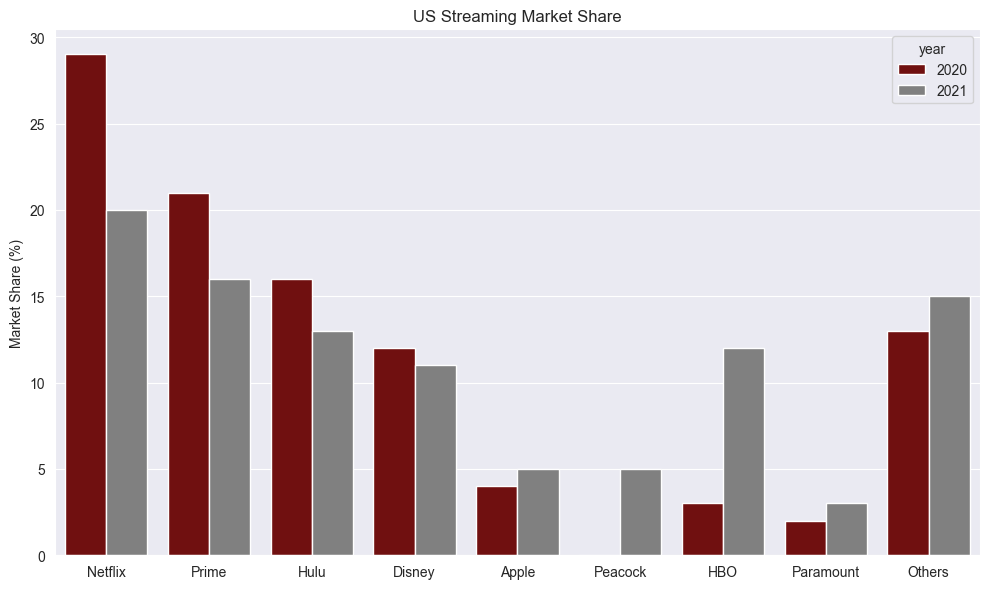

In [5]:
# Import pandas for data loading and reshaping
import pandas as pd
# Import matplotlib for lower-level chart customisation
import matplotlib.pyplot as plt
# Import seaborn for the high-level barplot function
import seaborn as sns
# Apply the 'darkgrid' style — gives the chart a dark grey background with white gridlines
sns.set_style('darkgrid')

# Read and tidy the data
# Load the streaming market share data from a CSV file
df = pd.read_csv("../data/streamingUS.csv")
# Reshape from wide format (one column per year) to tidy/long format (one row per year per service)
df_tidy = df.melt(id_vars=['order', 'service'], var_name='year', value_name='share')
# Convert year values from strings to integers so they behave correctly as categorical labels
df_tidy['year'] = df_tidy['year'].astype(int)
# Sort by year then by the original display order, and renumber the rows from 0
df_tidy = df_tidy.sort_values(['year', 'order']).reset_index(drop=True)

# Plot
# Create a figure 10 inches wide and 6 inches tall
plt.figure(figsize=(10, 6))
# Draw a grouped bar chart: one group per streaming service, two bars per group (one per year)
# hue='year' splits each service's bar by year; palette maps each year to a specific colour
sns.barplot(data=df_tidy, x='service', y='share', hue='year',
            palette={2020: 'maroon', 2021: 'grey'})

# Add a title to the chart
plt.title('US Streaming Market Share')
# Remove the x-axis label because the service names are self-explanatory
plt.xlabel('')
# Label the y-axis with the unit of measurement
plt.ylabel('Market Share (%)')
# Add a legend with the heading "year" to identify the two bar colours
plt.legend(title='year')
# Tighten the layout so titles and labels are not clipped
plt.tight_layout()
plt.show()

(c) Compute the year-on-year growth in market share for each service provider.\
Create a `growth` column to record the percentage change in share, and a `type` column with two possible values: `Loss` for negative growth, and `Gain` for positive growth.\
The first few rows should look like this:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>order</th>
      <th>service</th>
      <th>year</th>
      <th>share</th>
      <th>growth</th>
      <th>type</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Netflix</td>
      <td>2021</td>
      <td>20</td>
      <td>-9.0</td>
      <td>Loss</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Prime</td>
      <td>2021</td>
      <td>16</td>
      <td>-5.0</td>
      <td>Loss</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Hulu</td>
      <td>2021</td>
      <td>13</td>
      <td>-3.0</td>
      <td>Loss</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Disney</td>
      <td>2021</td>
      <td>11</td>
      <td>-1.0</td>
      <td>Loss</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Apple</td>
      <td>2021</td>
      <td>5</td>
      <td>1.0</td>
      <td>Gain</td>
    </tr>
  </tbody>
</table>
</div>

**Hint:**\
Read the documentation for the `diff` function here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.diff.html

In [6]:
# Type your code here:

# Compute year-on-year growth per service
# Sort so that for each service the 2020 row comes before the 2021 row — needed for diff() to work correctly
df_tidy = df_tidy.sort_values(['service', 'year'])

# For each service, subtract the previous year's share from the current year's share
# groupby('service') calculates the difference separately within each streaming provider
df_tidy['growth'] = df_tidy.groupby('service')['share'].diff()

# Keep only 2021 rows (diff gives NaN for 2020)
# The 2020 rows have NaN in 'growth' because there is no previous year to subtract from
df_growth = df_tidy[df_tidy['year'] == 2021].copy()

# Add type column
# Label each service as 'Gain' if its market share grew, or 'Loss' if it shrank
df_growth['type'] = df_growth['growth'].apply(lambda x: 'Gain' if x > 0 else 'Loss')

# Sort by order to match expected output
# Restore the original display order of the streaming services
df_growth = df_growth.sort_values('order').reset_index(drop=True)

print(df_growth.head())

   order  service  year  share  growth  type
0      1  Netflix  2021     20    -9.0  Loss
1      2    Prime  2021     16    -5.0  Loss
2      3     Hulu  2021     13    -3.0  Loss
3      4   Disney  2021     11    -1.0  Loss
4      5    Apple  2021      5     1.0  Gain


(d) Using the table above, recreate the following graph, as closely as you can.

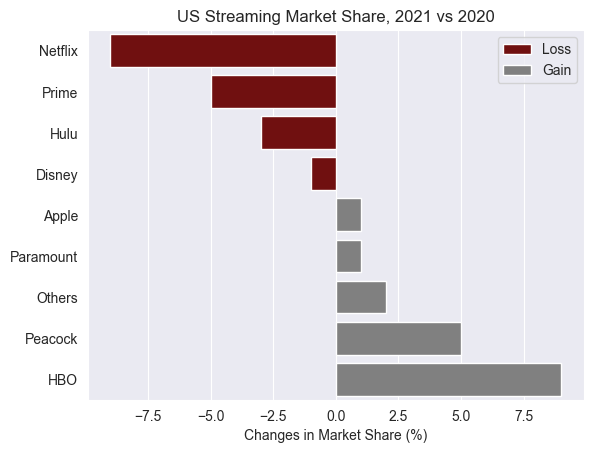

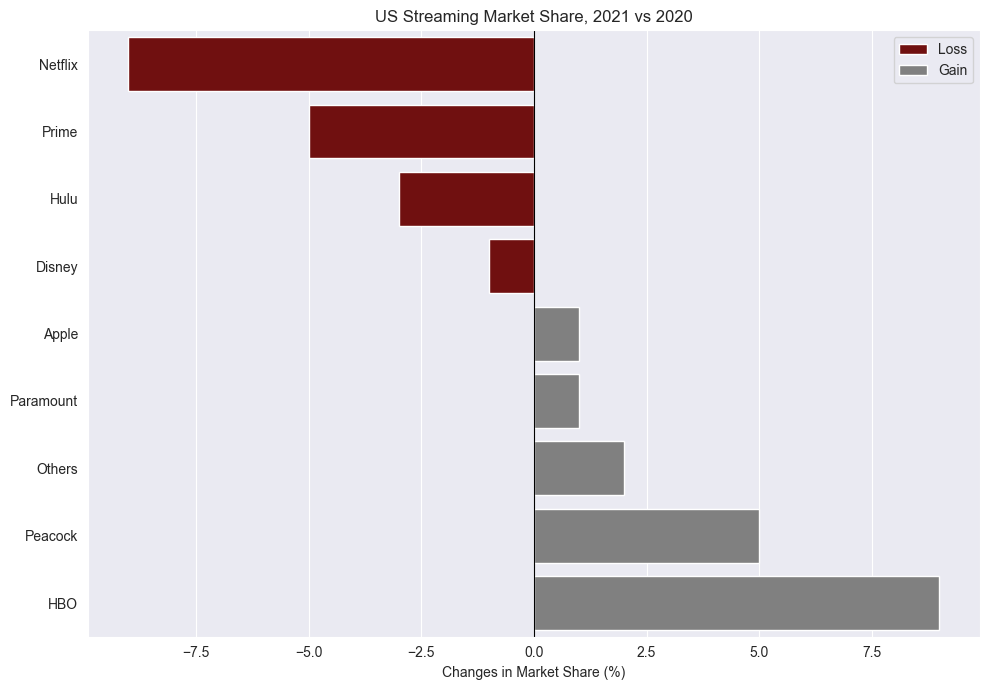

In [7]:
# Type your code here:

# Sort by growth value for the waterfall effect (Loss top, Gain bottom)
# Sorting ascending puts the most negative values (largest losses) at the top of the horizontal bar chart
df_growth_sorted = df_growth.sort_values('growth')

# Create a figure 10 inches wide and 7 inches tall
plt.figure(figsize=(10, 7))
# Draw a horizontal bar chart: x is the growth value, y is the streaming service name
# hue='type' colours bars by Gain/Loss; dodge=False overlaps bars on the same row (no double bars)
sns.barplot(data=df_growth_sorted, 
            x='growth',    # the length of each bar shows the size of the market share change
            y='service',   # one bar per streaming service
            hue='type',    # colour by whether the change was a gain or a loss
            palette={'Loss': 'maroon', 'Gain': 'grey'},  # dark red for losses, grey for gains
            dodge=False)   # draw all bars for the same service on the same row (no stacking)

# Add a descriptive title
plt.title('US Streaming Market Share, 2021 vs 2020')
# Label the x-axis to clarify what the bar lengths represent
plt.xlabel('Changes in Market Share (%)')
# Remove the y-axis label because the service names are self-explanatory
plt.ylabel('')
# Draw a thin vertical black line at x=0 to clearly mark the boundary between gains and losses
plt.axvline(x=0, color='black', linewidth=0.8)
# Add a legend with no title (blank string) since the colours are self-explanatory
plt.legend(title='')
# Tighten the layout so labels are not clipped
plt.tight_layout()
plt.show()

---
# 2. Human Development Index

The UN’s Human Development Index (HDI) is a composite measure that reflects a country’s performance in three aspects: health, education, and wealth. 

It ranges from 0 to 1 --- a value closer to 1 indicates that the country offers generally decent healthcare, education, and standard of living.

The file `UN_HDI_2021.xlsx` contains the HDI scores for 191 countries in 1990 and 2021.\
The file also contains a spreadsheet that groups the countries into broad geographical regions in the world.

(a) Read in the data and re-create, as much as you can, the following heatmap, which shows how HDI has changed for Indonesia, Malaysia and Singapore between 1990 and 2021.

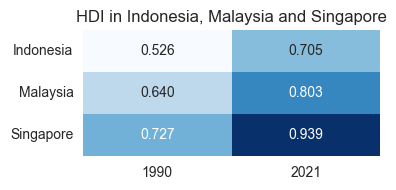

**Hint:**\
Read the documentation for `heatmap` here: https://seaborn.pydata.org/generated/seaborn.heatmap.html 



In [8]:
# Type your code here:

# Import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read the xlsx file using the default settings — this helps us see the raw structure first
df = pd.read_excel("../data/UN_HDI_2021.xlsx")

# Print the raw column names to understand how the file is structured (often has multi-row headers)
print(df.columns.tolist())
print(df.head())

# Read skipping the first 3 rows to use row 3 as header
# header=3 tells pandas to treat the 4th row (index 3) as the column names, skipping the title rows above
df = pd.read_excel("../data/UN_HDI_2021.xlsx", header=3)

# Rename columns to short, convenient names we will use throughout the analysis
df.columns = ['country', '1990', '2021']

# Drop any empty rows
# dropna(subset=['country']) removes rows where the 'country' cell is blank (e.g., separator rows in the Excel file)
df = df.dropna(subset=['country'])

print(df.head())

['Human Development Index trends, 1990 and 2021', 'Unnamed: 1', 'Unnamed: 2']
  Human Development Index trends, 1990 and 2021  \
0                                           NaN   
1                                           NaN   
2                                           NaN   
3                                       Country   
4                                   Switzerland   

                       Unnamed: 1  Unnamed: 2  
0                             NaN         NaN  
1  Human Development Index (HDI)          NaN  
2                           Value         NaN  
3                            1990    2021.000  
4                           0.851       0.962  
                  country   1990      2021
0                 Country   1990  2021.000
1             Switzerland  0.851     0.962
2                  Norway  0.838     0.961
3                 Iceland  0.811     0.959
4  Hong Kong, China (SAR)  0.788     0.952


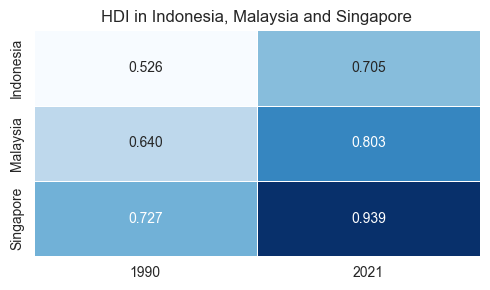

In [9]:
## Filter for 3 countries
# Define the three countries we want to compare in the heatmap
countries = ['Indonesia', 'Malaysia', 'Singapore']
# Keep only rows for these three countries and select the three relevant columns
df_filtered = df[df['country'].isin(countries)][['country', '1990', '2021']]
# Set country names as the row index so they appear as row labels in the heatmap
df_filtered = df_filtered.set_index('country')
# Reorder the rows to match the desired top-to-bottom order of countries
df_filtered = df_filtered.loc[countries]

# Convert to float
# The HDI values may have been read as strings; convert them to decimal numbers for the heatmap colour scale
df_filtered = df_filtered.astype(float)

# Plot heatmap
# Create a figure 5 inches wide and 3 inches tall — small because there are only 3 rows and 2 columns
plt.figure(figsize=(5, 3))
# Draw a heatmap where cell colour intensity reflects the HDI value
sns.heatmap(df_filtered,
            annot=True,     # display the actual HDI value inside each cell
            fmt='.3f',      # format the numbers to 3 decimal places (e.g., 0.762)
            cmap='Blues',   # use a blue colour scale — darker blue means higher HDI
            cbar=False,     # hide the colour bar legend to keep the chart compact
            linewidths=0.5) # draw thin lines between cells to separate them visually

# Add a descriptive title
plt.title('HDI in Indonesia, Malaysia and Singapore')
# Remove axis labels because the row/column headers already explain the data
plt.xlabel('')
plt.ylabel('')
# Tighten the layout to prevent the title from being clipped
plt.tight_layout()
plt.show()

(b) We next explore the changes in HDI between 1990 and 2021 for all countries in the data across five regions of Africa, Americas, Asia,  Europe and Oceania. 

To do that, first prepare the HDI data above in tidy format, and "join" it with the information given in `Sheet 2` to include a `Region.Name` column.\
The tidy table should look like this:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Country</th>
      <th>year</th>
      <th>hdi</th>
      <th>iso3</th>
      <th>Region.Name</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Switzerland</td>
      <td>1990</td>
      <td>0.851</td>
      <td>CHE</td>
      <td>Europe</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Norway</td>
      <td>1990</td>
      <td>0.838</td>
      <td>NOR</td>
      <td>Europe</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Iceland</td>
      <td>1990</td>
      <td>0.811</td>
      <td>ISL</td>
      <td>Europe</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Hong Kong, China (SAR)</td>
      <td>1990</td>
      <td>0.788</td>
      <td>HKG</td>
      <td>Asia</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Australia</td>
      <td>1990</td>
      <td>0.865</td>
      <td>AUS</td>
      <td>Oceania</td>
    </tr>
  </tbody>
</table>
</div>


In [10]:
# Type your code here

# Check sheet names and Sheet 2 structure
# List all sheet names in the Excel file to confirm which sheet index corresponds to the regions data
print(pd.ExcelFile("../data/UN_HDI_2021.xlsx").sheet_names)

# Load the second sheet (index 1) which contains country-to-region mappings
df_regions = pd.read_excel("../data/UN_HDI_2021.xlsx", sheet_name=1)
# Preview the first 10 rows of the regions sheet to understand its structure
print(df_regions.head(10))
# Print the column names so we know the exact names to use when merging later
print(df_regions.columns.tolist())

['Sheet1', 'Sheet2']
  iso3               country Region.Name
0  AFG           Afghanistan        Asia
1  AGO                Angola      Africa
2  ALB               Albania      Europe
3  AND               Andorra      Europe
4  ARE  United Arab Emirates        Asia
5  ARG             Argentina    Americas
6  ARM               Armenia        Asia
7  ATG   Antigua and Barbuda    Americas
8  AUS             Australia     Oceania
9  AUT               Austria      Europe
['iso3', 'country', 'Region.Name']


In [11]:
# Read Sheet 2 — this sheet maps each country to its ISO3 code and geographic region
df_regions = pd.read_excel("../data/UN_HDI_2021.xlsx", sheet_name=1)

# Melt HDI data to tidy format
# Reshape the HDI table from wide (columns: '1990', '2021') to long (one row per country per year)
df_tidy = df.melt(id_vars=['country'], var_name='year', value_name='hdi')
# Convert year from string (e.g., "1990") to integer so it plots and sorts correctly
df_tidy['year'] = df_tidy['year'].astype(int)

# Rename to match expected output
# Rename 'country' to 'Country' (capital C) to match the expected output column name
df_tidy = df_tidy.rename(columns={'country': 'Country'})

# Merge with regions
# Join the HDI tidy table with the regions sheet so each row gains an iso3 code and a region name
# how='left' keeps all HDI rows even if a country has no matching region
df_merged = df_tidy.merge(df_regions[['country', 'iso3', 'Region.Name']], 
                           left_on='Country',   # match on 'Country' in the HDI table
                           right_on='country',  # match on 'country' in the regions table
                           how='left').drop(columns='country')  # drop the duplicate 'country' column from regions

# Sort by year then hdi descending to match expected output
# Ascending year (1990 first, 2021 second), descending HDI (highest scores first within each year)
df_merged = df_merged.sort_values(['year', 'hdi'], ascending=[True, False]).reset_index(drop=True)

# Reorder columns to match expected output
df_merged = df_merged[['Country', 'year', 'hdi', 'iso3', 'Region.Name']]

print(df_merged.head())

         Country  year hdi iso3 Region.Name
0  Liechtenstein  1990  ..  LIE      Europe
1       Slovenia  1990  ..  SVN      Europe
2        Andorra  1990  ..  AND      Europe
3        Croatia  1990  ..  HRV      Europe
4     San Marino  1990  ..  SMR      Europe


(c) Create the following slope chart that visualises how the HDI has changed for countries between 1990 and 2001.

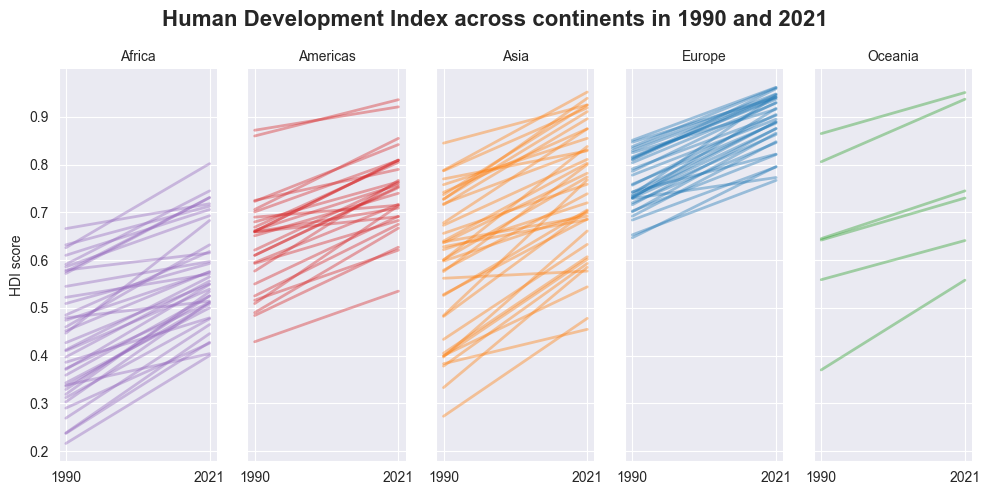

**Hint:**\
Read the documentation for 
- `relplot` here: https://seaborn.pydata.org/generated/seaborn.relplot.html
- `lineplot` here: https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot

In [12]:
# Check what countries look like in each sheet
# Print the first 10 country names from the HDI sheet to inspect how they are formatted
print("Sheet 1 countries:")
print(df['country'].head(10).tolist())

# Print the first 10 country names from the regions sheet to see if spellings match
print("\nSheet 2 countries:")
print(df_regions['country'].head(10).tolist())

# Check how many matched after merge
# A non-null Region.Name means the country was successfully matched; null means no match was found
print("\nRegion.Name null count:", df_merged['Region.Name'].isna().sum())
# Print the total number of rows to understand the full scope of the dataset
print("Total rows:", len(df_merged))

Sheet 1 countries:
['Country', 'Switzerland', 'Norway', 'Iceland', 'Hong Kong, China (SAR)', 'Australia', 'Denmark', 'Sweden', 'Ireland', 'Germany']

Sheet 2 countries:
['Afghanistan', 'Angola', 'Albania', 'Andorra', 'United Arab Emirates', 'Argentina', 'Armenia', 'Antigua and Barbuda', 'Australia', 'Austria']

Region.Name null count: 6
Total rows: 388


In [13]:
# Remove the rogue 'Country' header row from df
# The Excel file has a literal text row "Country" at the top — filter it out before analysis
df = df[df['country'] != 'Country'].copy()

# Melt HDI data to tidy format
# Reshape the table from wide to long: one row per country-year combination
df_tidy = df.melt(id_vars=['country'], var_name='year', value_name='hdi')
# Convert year from string to integer for correct sorting and plotting
df_tidy['year'] = df_tidy['year'].astype(int)
# Rename 'country' to 'Country' to match the expected output column name
df_tidy = df_tidy.rename(columns={'country': 'Country'})

# Merge with regions
# Join the tidy HDI table with the regions mapping to add iso3 codes and region names
df_merged = df_tidy.merge(df_regions[['country', 'iso3', 'Region.Name']], 
                           left_on='Country',   # match on 'Country' from the HDI table
                           right_on='country',  # match on 'country' from the regions table
                           how='left').drop(columns='country')  # remove the duplicate 'country' column

# Sort rows: 1990 rows first, then 2021; within each year sort by HDI from highest to lowest
df_merged = df_merged.sort_values(['year', 'hdi'], ascending=[True, False]).reset_index(drop=True)
# Keep only the five expected output columns in the correct order
df_merged = df_merged[['Country', 'year', 'hdi', 'iso3', 'Region.Name']]

# Check remaining NaN after fix
# After removing the header row, count how many countries still failed to match a region
print("Region.Name null count:", df_merged['Region.Name'].isna().sum())
print(df_merged.head())

Region.Name null count: 4
         Country  year hdi iso3 Region.Name
0  Liechtenstein  1990  ..  LIE      Europe
1       Slovenia  1990  ..  SVN      Europe
2        Andorra  1990  ..  AND      Europe
3        Croatia  1990  ..  HRV      Europe
4     San Marino  1990  ..  SMR      Europe


         Country  year    hdi iso3 Region.Name
0  United States  1990  0.872  USA    Americas
1      Australia  1990  0.865  AUS     Oceania
2         Canada  1990  0.860  CAN    Americas
3    Switzerland  1990  0.851  CHE      Europe
4    Netherlands  1990  0.847  NLD      Europe


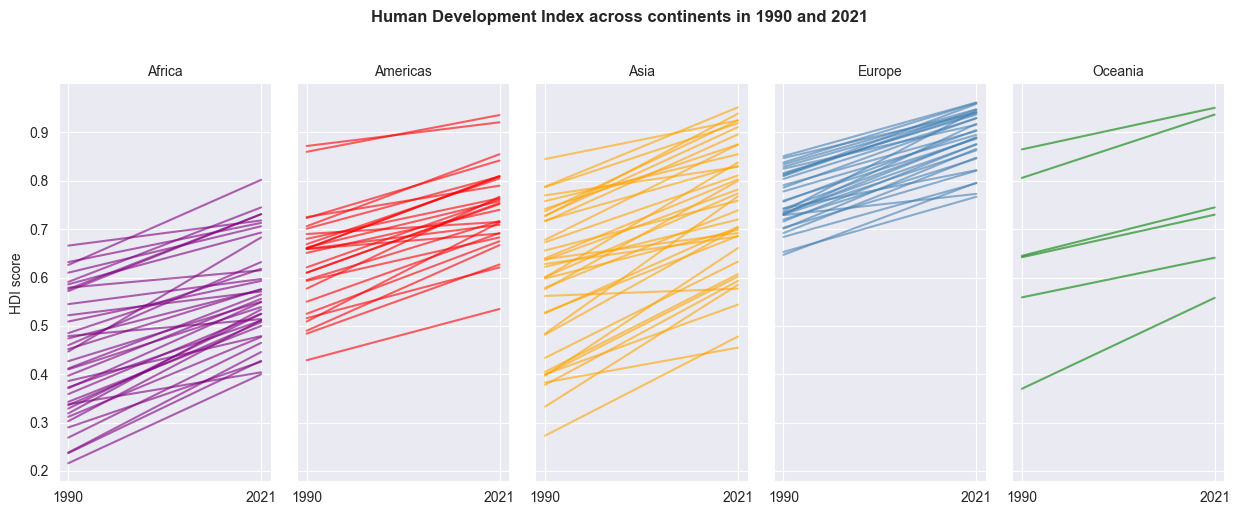

In [14]:
# ── Part (b): Tidy + merge ────────────────────────────────────
# Reshape the HDI table from wide to long format: one row per country-year combination
df_tidy = df.melt(id_vars=['country'], var_name='year', value_name='hdi')
# Convert year from string to integer so it plots on a numeric axis
df_tidy['year'] = df_tidy['year'].astype(int)
# Convert hdi values to numeric, replacing any non-numeric entries (e.g., "..") with NaN
df_tidy['hdi'] = pd.to_numeric(df_tidy['hdi'], errors='coerce')
# Rename 'country' to 'Country' to match the expected output column name
df_tidy = df_tidy.rename(columns={'country': 'Country'})

# Join the tidy HDI data with the regions sheet to add iso3 codes and region names to each row
df_merged = df_tidy.merge(df_regions[['country', 'iso3', 'Region.Name']],
                           left_on='Country',   # match using the 'Country' column from the HDI table
                           right_on='country',  # match using the 'country' column from the regions table
                           how='left').drop(columns='country')  # remove the duplicate country column from regions

# Sort rows: 1990 first, then 2021; within each year sort by HDI from highest to lowest
df_merged = df_merged.sort_values(['year', 'hdi'], ascending=[True, False]).reset_index(drop=True)
# Keep only the five required columns in the expected order
df_merged = df_merged[['Country', 'year', 'hdi', 'iso3', 'Region.Name']]

print(df_merged.head())

# ── Part (c): Slope chart ─────────────────────────────────────
# Define the five regions we want to display as separate panels
regions = ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']
# Keep only rows belonging to one of these five regions
df_plot = df_merged[df_merged['Region.Name'].isin(regions)].copy()
# Remove rows where the Country value is missing
df_plot = df_plot[df_plot['Country'].notna()]
# Remove any rows where Country is not a proper string (e.g., numeric artefacts from reading Excel)
df_plot = df_plot[df_plot['Country'].apply(lambda x: isinstance(x, str))]
# Drop rows that have no HDI value or no region — these cannot be plotted
df_plot = df_plot.dropna(subset=['hdi', 'Region.Name'])
# Reset the row index after all the filtering
df_plot = df_plot.reset_index(drop=True)

# Draw the slope chart using seaborn's relplot — one panel (column) per region
g = sns.relplot(data=df_plot,
                x='year',          # x-axis: the two years (1990 and 2021)
                y='hdi',           # y-axis: the HDI score
                hue='Region.Name', # colour lines by region
                col='Region.Name', # create one subplot panel per region
                units='Country',   # draw one line per country (not an average)
                estimator=None,    # do not aggregate — plot every individual country line
                kind='line',       # use a line chart to connect the two data points per country
                col_order=regions, # display panels in the specified left-to-right order
                palette={'Africa': 'purple',    # assign a distinct colour to each region
                         'Americas': 'red',
                         'Asia': 'orange',
                         'Europe': 'steelblue',
                         'Oceania': 'green'},
                height=5,          # each panel is 5 inches tall
                aspect=0.5,        # each panel's width is 0.5 × height = 2.5 inches wide
                alpha=0.6,         # make lines 60% opaque so overlapping lines remain visible
                legend=False)      # hide the legend because the panel titles already identify each region

# Label the axes — empty string removes the x-axis label since the tick marks (1990, 2021) are clear
g.set_axis_labels('', 'HDI score')
# Set each panel's title to its region name
g.set_titles('{col_name}')
# Add an overall chart title above all panels; y=1.02 pushes it slightly above the panels
g.figure.suptitle('Human Development Index across continents in 1990 and 2021',
                   fontweight='bold', y=1.02)

# Show only 1990 and 2021 on the x-axis of every panel to keep the display uncluttered
for ax in g.axes.flat:
    ax.set_xticks([1990, 2021])

# Adjust spacing so panels and title don't overlap
plt.tight_layout()
plt.show()